# 06 — Зафиксированная модель, holdout и answer.csv

Сначала один раз оцениваем выбор из `05` на нетронутом `test`. После этого параметры не меняем.
Затем переобучаем fusion на доступных OOF-кандидатах всех трёх частей и строим поведенческие
источники на всех train-парах. Это финальное обучение после оценки, не новый честный test score.

Для benchmark retrieval разрешены только items из benchmark_items. Локальный каталог больше;
поэтому поиск повторяется с фильтром **до top-k**, а не простым удалением чужих IDs из готовой выдачи.

In [1]:
from pathlib import Path
import sys
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
su_root = Path.cwd() if (Path.cwd() / 'src').exists() else Path.cwd().parent
if str(su_root) not in sys.path: sys.path.insert(0,str(su_root))
su_out = su_root / 'outputs'
su_seed = 143
from src.data import write_json
from src.validation import recall_table, bootstrap_ci
from src.retrieval import predictions_from_frame, rrf

In [2]:
import joblib
import torch
from catboost import CatBoostClassifier
from src.data import load_raw, prepare_queries
from src.features import item_features
from src.retrieval import LexicalIndex, HistoryIndex, dense_search
from src.fusion import candidate_features, model_matrix
from src.validation import save_submission, validate_submission
su_items=pd.read_parquet(su_out / 'cache/items.parquet')
su_numeric=pd.read_parquet(su_out / 'cache/item_features.parquet')
su_queries=pd.read_parquet(su_out / 'cache/eval_queries.parquet')
su_test=su_queries[su_queries.split.eq('test')]
su_truth_all=json.loads((su_out / 'cache/truth.json').read_text())
su_truth={q:su_truth_all[q] for q in su_test.query_id}
su_selected=json.loads((su_out / 'models/selected.json').read_text())
su_columns=json.loads((su_out / 'models/fusion_features.json').read_text())['features']
su_test_features=pd.read_parquet(su_out / 'cache/fusion_test.parquet')
su_model=CatBoostClassifier(); su_model.load_model(str(su_out / 'models/fusion.cbm'))
if su_selected['method'].startswith('catboost'):
    su_scores=su_model.predict_proba(model_matrix(su_test_features,su_columns),ntree_end=su_selected['ntree'])[:,1]
    su_pred=predictions_from_frame(su_test_features.assign(score=su_scores),su_items,score='score',k=100)
else:
    su_pred=predictions_from_frame(su_test_features,su_items,score='rrf',k=100)
su_result=recall_table(su_pred,su_truth).merge(su_test[['query_id','regime','text_key']],on='query_id')
su_slices=pd.read_parquet(su_out / 'validation/query_slices.parquet')
su_result=su_result.merge(su_slices[['query_id','cold_item_fraction','new_pair_fraction','query_train_frequency']],on='query_id')
su_result.to_parquet(su_out / 'validation/holdout_per_query.parquet',index=False)
su_summary=[]
for su_regime,su_part in su_result.groupby('regime'):
    su_ci=bootstrap_ci(su_part['recall@50'])
    su_summary.append({'regime':su_regime,'queries':len(su_part),**su_part.filter(like='recall@').mean().to_dict(),'ci95_low':su_ci[0],'ci95_high':su_ci[1]})
su_summary=pd.DataFrame(su_summary)
su_summary.to_csv(su_out / 'validation/holdout.csv',index=False)
display(su_summary)
display(su_result.groupby(['regime',su_result.cold_item_fraction.eq(1).rename('all_items_cold')])['recall@50'].agg(['mean','count']))
display(su_result.groupby(['regime',su_result.new_pair_fraction.eq(1).rename('all_pairs_new')])['recall@50'].agg(['mean','count']))
su_coverage=recall_table(predictions_from_frame(su_test_features,su_items,k=100000),su_truth,ks=(100000,))
su_coverage=su_coverage.merge(su_test[['query_id','regime']],on='query_id')
su_coverage.to_csv(su_out / 'validation/holdout_pool_ceiling.csv',index=False)
su_selected['test_opened']=True
write_json(su_selected,su_out / 'models/selected.json')

,regime,queries,recall@1,recall@10,recall@20,recall@50,recall@100,ci95_low,ci95_high
0,cold,1000,0.261167,0.640917,0.720458,0.807542,0.842167,0.781373,0.832000
1,warm,1000,0.276841,0.651347,0.738822,0.810980,0.846876,0.786636,0.834424


mean  count
regime all_items_cold                 
cold   False           0.793955    346
       True            0.814730    654
warm   False           0.790026    368
       True            0.823180    632

mean  count
regime all_pairs_new                 
cold   True           0.807542   1000
warm   False          0.811186     51
       True           0.810968    949

## Анализ ошибок без ручной правки ответов
Примеры нужны для ревью, а не для хардкода под query_id. Идентификаторы теста не используются как признаки.

,query_id,query,regime,truth_titles,predicted_titles
0,0088a4217476370cb79c2871,безвоздушная покраска,cold,"[Покраска безвоздушная стен, потолков, фасадов]","[Безвоздушная покраска, Безвоздушная покраска,..."
1,028800792289d2033e7e9842,настройка турбины,cold,[Прошивка эбу на мощность Чип-тюнинг Stage 1],"[Ремонт грузовых и легковых турбокомпрессоров,..."
2,0305672915b6eef95f85b8c4,коррекция волос,cold,[Наращивание волос Сочи],"[Модель на наращивание волос, Окрашивание воло..."
3,032dbf6098212013524ef1f0,курьер,warm,[Грузчики],"[Курьер, Доставка перевозка авто курьер, Курье..."
4,03524277bd90b6e8ce3c6be2,беседка в аренду,warm,"[Аренда Домики, беседки, шатры 6-80 чел у озера]","[Аренда беседки Беседка в аренду, Беседка в ар..."
5,047c2f8c92221a56757b32ed,пишу конспекты,warm,"[Курсовая работа, диплом, ВКР, отчёт по практике]","[Пишу конспекты от руки, Перепишу от руки лекц..."
6,04f4dc31e5cff3769c1e8547,автосервис опель,cold,[Автосервис Гудзон в Одинцово],"[Автосервис Опель, Opel сервис, Ремонт Opel Ch..."
7,05f010a33f65300f34456951,бетонщики,warm,[Фундамент под ключ / Заливка фундамента],"[Каменщики - Бетонщики, Строительство фундамен..."
8,06a89adaf423057530037de6,белый мишка,cold,[Поздравление от Мишки Белого; Гуся- обнимуся],"[Белый мишка поздравление на праздник, Белый м..."
9,07486fdc51ee41ba206a9d10,вода доставка,cold,[Доставка подвоз технической питьевой чистой в...,"[Вода доставка, Водовоз, доставка воды, Технич..."


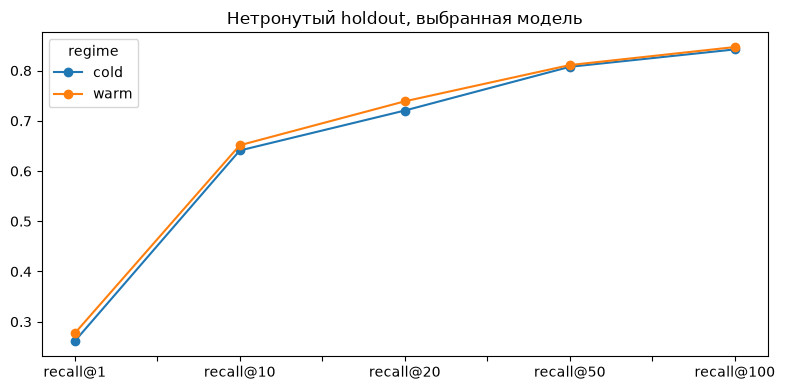

In [3]:
su_lookup=su_items.set_index('item_id')
su_errors=[]
for su_row in su_result.sort_values(['recall@50','query_id']).head(30).itertuples():
    su_q=su_test.set_index('query_id').loc[su_row.query_id]
    su_errors.append({'query_id':su_row.query_id,'query':su_q.search_query,'regime':su_row.regime,
        'truth_titles':[su_lookup.loc[i,'item_title_raw'] for i in su_truth[su_row.query_id]],
        'predicted_titles':[su_lookup.loc[i,'item_title_raw'] for i in su_pred.get(su_row.query_id,[])[:5]]})
write_json(su_errors,su_out / 'validation/error_examples.json')
display(pd.DataFrame(su_errors).head(10))
su_summary.set_index('regime')[['recall@1','recall@10','recall@20','recall@50','recall@100']].T.plot(marker='o',figsize=(8,4),title='Нетронутый holdout, выбранная модель')
plt.tight_layout(); plt.savefig(su_out / 'figures/holdout_recall_curve.png',dpi=150); plt.show()

In [4]:
if su_selected['method'].startswith('catboost'):
    su_oof=pd.concat([pd.read_parquet(su_out / f'cache/fusion_{part}.parquet') for part in ['rank_train','dev','test']],ignore_index=True)
    su_ids=su_items.item_id.to_numpy()
    su_oof['target']=[int(su_ids[p] in su_truth_all[q]) for q,p in zip(su_oof.query_id,su_oof.pos)]
    su_npos=su_oof.groupby('query_id').target.transform('sum')
    su_oof=su_oof[su_npos.gt(0)].copy()
    su_npos=su_oof.groupby('query_id').target.transform('sum')
    su_n=su_oof.groupby('query_id').target.transform('size')
    su_w=np.where(su_oof.target.eq(1),.5/su_npos,.5/(su_n-su_npos).clip(lower=1)); su_w=su_w/su_w.mean()
    su_final=CatBoostClassifier(iterations=su_selected['ntree'],depth=6,learning_rate=.07,loss_function='Logloss',
        l2_leaf_reg=5,random_seed=su_seed,thread_count=4,allow_writing_files=False,verbose=100)
    su_final.fit(model_matrix(su_oof,su_columns),su_oof.target,sample_weight=su_w)
    su_final.save_model(str(su_out / 'models/fusion_final.cbm'))
    del su_oof

0:	learn: 0.6243816	total: 345ms	remaining: 1m 43s


100:	learn: 0.2117732	total: 27.5s	remaining: 54.2s


200:	learn: 0.1944769	total: 54.2s	remaining: 26.7s


299:	learn: 0.1780764	total: 1m 20s	remaining: 0us


## Финальный корпус и переиндексация
Corpus-derived TF-IDF/BM25 допускают использование всей известной коллекции документов.
Здесь берём строки уже обученного индекса только для benchmark; IDF остаётся обученным на общем каталоге.
Top-k выполняется заново по ограниченной матрице. Это не потеря кандидатов из-за фильтра после retrieval.

In [5]:
su_train_raw,su_bq_raw,su_bi_raw=load_raw()
su_bq=prepare_queries(su_bq_raw)
su_mask=su_items.item_id.isin(su_bi_raw.item_id).to_numpy()
su_positions=np.flatnonzero(su_mask)
su_bitems=su_items.iloc[su_positions].reset_index(drop=True)
su_bnumeric=su_numeric.iloc[su_positions].reset_index(drop=True)
su_centers=su_items.groupby('item_location_id')[['item_latitude','item_longitude']].median()
su_full_pairs=prepare_queries(su_train_raw)
su_full_pairs['item_id']=su_train_raw.item_id.to_numpy()
su_full_pairs=su_full_pairs.drop_duplicates(['context_key','item_id'])
su_index=joblib.load(su_out / 'cache/lexical_index.joblib')
for su_attribute in ['word_matrix','bm25','overlap','title_bm25','char_matrix']:
    setattr(su_index,su_attribute,getattr(su_index,su_attribute)[su_positions])
su_candidates=su_index.search(su_bq,su_bitems,k=120,methods=['word','char','bm25','bm25_title'])
su_history=HistoryIndex().fit(su_full_pairs,su_bitems,label_catalog=su_items)
su_history_candidates=su_history.search(su_bq,k=120)
su_candidates=pd.concat([su_candidates,su_history_candidates],ignore_index=True)
# Вектора запросов benchmark рассчитаны в 04 тем же encoder.
su_emb_ids=pd.read_parquet(su_out / 'cache/embedding_query_ids.parquet').query_id.tolist()
su_qpos=dict(zip(su_emb_ids,range(len(su_emb_ids))))
su_qvectors=np.load(su_out / 'cache/query_embeddings.npy')[[su_qpos[q] for q in su_bq.query_id]]
su_qadapted=np.load(su_out / 'cache/query_embeddings_adapted.npy')[[su_qpos[q] for q in su_bq.query_id]]
su_ivectors=np.array(np.load(su_out / 'cache/item_embeddings.npy',mmap_mode='r')[su_positions])
su_dense=dense_search(su_qvectors,su_ivectors,su_bq,su_bitems,k=120)
su_adapted=dense_search(su_qadapted,su_ivectors,su_bq,su_bitems,k=120)
su_adapted['source']=su_adapted.source.str.replace('dense','adapted')
su_candidates=pd.concat([su_candidates,su_dense,su_adapted],ignore_index=True)
su_candidates.to_parquet(su_out / 'cache/benchmark_candidates.parquet',index=False)
su_bfeatures=candidate_features(su_candidates,su_bq,su_bitems,su_bnumeric,su_full_pairs.item_id.value_counts().to_dict(),
    su_selected['weights'],dict(zip(su_bq.query_id,su_qvectors)),su_ivectors,max_candidates=400,centers=su_centers)
if su_selected['method'].startswith('catboost'):
    su_score=su_final.predict_proba(model_matrix(su_bfeatures,su_columns))[:,1]
    su_predictions=predictions_from_frame(su_bfeatures.assign(score=su_score),su_bitems,score='score',k=50)
else:
    su_predictions=predictions_from_frame(su_bfeatures,su_bitems,score='rrf',k=50)
# Rare empty queries: deterministic popularity backfill, только из benchmark.
su_popularity=sorted(su_bitems.item_id,key=lambda i:(-su_history.pop.get(i,0),i))
for su_qid in su_bq.query_id:
    su_top=su_predictions.get(su_qid,[])
    su_predictions[su_qid]=(su_top+[i for i in su_popularity[:100] if i not in set(su_top)])[:50]
su_path=su_out / 'submissions/answer.csv'
su_validation=save_submission(su_predictions,su_bq,su_bitems,su_path)
write_json(su_validation,su_out / 'submissions/validation.json')
print(su_path)
display(su_validation)
display(pd.read_csv(su_path,dtype=str,keep_default_na=False).head())

word: 2452 queries, 17.5s


char: 2452 queries, 8.1s


bm25: 2452 queries, 16.1s


bm25_title: 2452 queries, 1.2s


/Users/dvsorochan/.codex/.chatgpt-projects/g-p-6ab7bad8eeb481919ab7a788d369d736/avito_candidate_generation/outputs/submissions/answer.csv


{'rows': 2452, 'min_candidates': 50, 'max_candidates': 50, 'valid': True}

,query_id,answer
0,70DfDUpwjxB4lzFd,b92ee8f432cec2d1 fa01652ca5f57d0f d722bcda1a55...
1,JTrdTaZJvSiLPkXj,16ea26ff0aa0450a 422d3ffdd5bbf626 413f6384e3c0...
2,LZCZNoVG4AFUkVRJ,168a9207e80b0be4 3b370cc603f67947 d8fce513e4f0...
3,660ac9QVtXkRxZC3,bd2cb4500fad728e a846a2a5241e1180 4c15e7abba06...
4,YgHcM9MVbxKnxD1e,1a62634394544781 ba78ad593ec3412d 94cce9ac398a...


## Что означает результат

Порядок внутри 50 не влияет на Recall@50, но нужен при построении промежуточных top-k.
Local holdout score не является оценкой скрытого leaderboard: отличаются каталог, отбор запросов
и доля cold items. Все цифры в outputs получены запуском, без ручного восстановления test labels.
Исходные Parquet не меняются. Git commit/push и отправка ответа на платформу не выполняются.